# Question 5: Coding — Gradient Descent for Matrix Factorization (40 pts)

This is a challenging problem that puts everything together. You will implement a gradient descent solver for the matrix factorization problem. Your goal is to find two matrices, $P \in \mathbb{R}^{m \times k}$ and $Q \in \mathbb{R}^{n \times k}$, whose product $PQ^\top$ approximates a given data matrix $R \in \mathbb{R}^{m \times n}$. We will simplify the problem slightly by assuming all entries of $R$ are observed.

**The objective function is:**

$$ f(P, Q) = \frac{1}{2} \|R - PQ^\top\|_F^2 $$

**The gradients are:**

$$ \nabla_P f = -(R - PQ^\top)Q $$

$$ \nabla_Q f = -(R - PQ^\top)^\top P $$


## (a) Data Generation

Create a synthetic "ground truth" data matrix.

- Create random matrices $P_{\text{true}} \in \mathbb{R}^{50 \times 5}$ and $Q_{\text{true}} \in \mathbb{R}^{100 \times 5}$.
- Form the target matrix $R = P_{\text{true}} Q_{\text{true}}^\top$. This creates a $50 \times 100$ matrix.

In [1]:
import numpy as np

np.random.seed(42)
m, n, k = 50, 100, 5

P_true = np.random.randn(m, k)
Q_true = np.random.randn(n, k)
R = P_true @ Q_true.T

print(f"P_true shape: {P_true.shape}")
print(f"Q_true shape: {Q_true.shape}")
print(f"R shape: {R.shape}")
print(f"R rank: {np.linalg.matrix_rank(R)}")

P_true shape: (50, 5)
Q_true shape: (100, 5)
R shape: (50, 100)
R rank: 5



## (b) Implementation

Write a Python script that implements gradient descent to find $P$ and $Q$.

- Initialize $P$ and $Q$ with small random values (e.g., from `np.random.rand(m, k) * 0.1`). Use $k = 5$.
- Write a loop that runs for a fixed number of iterations (e.g., 2000).
- Per iteration, compute the predicted matrix $\hat{R} = PQ^\top$ and the error matrix $E = R - \hat{R}$.
- Compute the gradients for $P$ and $Q$ using the formulas above.
- Update $P$ and $Q$ using the gradient descent rule: $P_{t+1} = P_t - \varepsilon \nabla_P f$ and $Q_{t+1} = Q_t - \varepsilon \nabla_Q f$. You will need to tune the learning rate $\varepsilon$ (start with something small like `0.001`).
- Calculate and store the cost $f(P, Q) = \frac{1}{2}\|E\|_F^2$ at each iteration.

In [8]:

P = np.random.rand(m, k) * 0.1
Q = np.random.rand(n, k) * 0.1

learning_rate = 0.001
iterations = 2000
cost_history = []

def matrix_factorization_gd(R, k=5, lr=0.001, iterations=2000, seed=0):
    np.random.seed(seed)
    m, n = R.shape

    P = np.random.rand(m, k) * 0.1
    Q = np.random.rand(n, k) * 0.1
    cost_history = []

    for i in range(iterations):
        R_hat = P @ Q.T
        E = R - R_hat

        grad_P = -E @ Q
        grad_Q = -E.T @ P

        P = P - lr * grad_P
        Q = Q - lr * grad_Q

        cost = 0.5 * np.linalg.norm(E, 'fro')**2
        cost_history.append(cost)

    return P, Q, cost_history

P, Q, cost_history = matrix_factorization_gd(R, k=5, lr=0.001, iterations=2000)
print(f"Final cost: {cost_history[-1]:.6e}")

Final cost: 2.468246e-26



## (c) Analysis

- Plot the cost history versus the iteration number.
- After the loop finishes, compute the final predicted matrix $\hat{R}_{\text{final}} = PQ^\top$.
- Calculate the final reconstruction error as $\|R - \hat{R}_{\text{final}}\|_F$. Report this value. Does your algorithm successfully recover the original matrix?

Plot saved as 'MF.png'


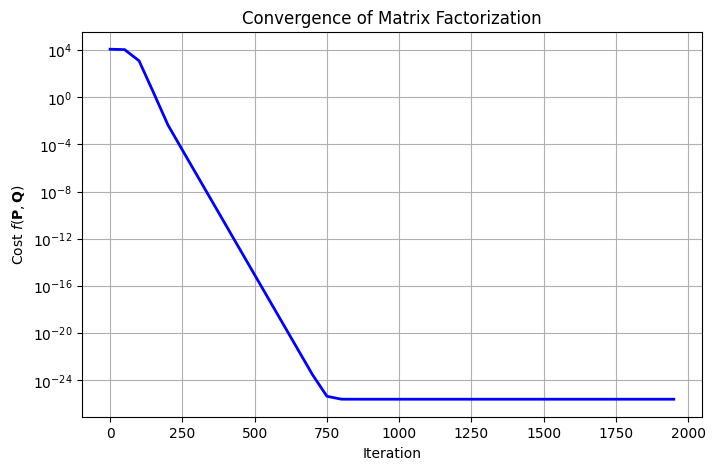

Final reconstruction error: ||R - R_final||_F = 2.221822e-13


In [9]:

import matplotlib.pyplot as plt

# Plot cost history
plt.figure(figsize=(8, 5))
plt.plot(range(0, len(cost_history), 50), cost_history[::50], 'b-', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel(r"Cost $f(\mathbf{P}, \mathbf{Q})$")
plt.title("Convergence of Matrix Factorization")
plt.yscale('log')
plt.grid(True)
plt.savefig('MF.png', bbox_inches='tight')
print("Plot saved as 'MF.png'")
plt.show()

# Final reconstruction error
R_final = P @ Q.T
final_error = np.linalg.norm(R - R_final, 'fro')
print(f"Final reconstruction error: ||R - R_final||_F = {final_error:.6e}")